In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fedesoriano/cifar100/meta
/kaggle/input/datasets/fedesoriano/cifar100/file.txt
/kaggle/input/datasets/fedesoriano/cifar100/test
/kaggle/input/datasets/fedesoriano/cifar100/train


# 0: Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# 1: Patch Embedding

**The paper's whole trick starts here:** an image `(H, W, C)` is not naturally a sequence. We chop it into a grid of `P×P` patches, flatten each patch, and linearly project it to a D-dimensional vector — exactly like how a word gets an embedding vector in NLP.

For a `32×32` CIFAR image (much smaller than ImageNet's 224×224!) with patch size P=4, you'd get N = (32/4)² = 64 patches. We'll pick patch size thoughtfully since CIFAR is small — more on that when we get to the full model.

## The implementation trick

Instead of manually slicing the image into patches, flattening, and matrix-multiplying by E — the paper notes this is mathematically identical to a single Conv2d with kernel_size = P and stride = P. The convolution slides non-overlapping P×P windows and each one gets projected to D output channels — that's exactly "flatten patch → linear projection," just expressed as a conv.

In [3]:
class PatchEmbedding(nn.Module):
    """
    Splits image into patches and linearly projects each to embedding dim D.
    Equivalent to: flatten each PxP patch -> Linear(P*P*C, D)
    Implemented as a single strided Conv2d for efficiency.
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # Conv with kernel_size = stride = patch_size => non-overlapping patches
        # Each patch (patch_size x patch_size x in_channels) gets projected to embed_dim
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)                # -> (B, embed_dim, H/P, W/P)
        x = x.flatten(2)                # -> (B, embed_dim, num_patches)
        x = x.transpose(1, 2)           # -> (B, num_patches, embed_dim)
        return x

In [4]:
pe = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=192)
dummy_img = torch.randn(8, 3, 32, 32)  # batch of 8 CIFAR-sized images
out = pe(dummy_img)
print(out.shape)  # expect: (8, 64, 192)  -> (batch, num_patches, embed_dim)

torch.Size([8, 64, 192])


# 2: [class] Token + Position Embeddings
## Why the [class] token?

The Transformer encoder outputs one vector per input token — so after encoding, we'd have 64 output vectors (one per patch), but for classification we need one single vector representing the whole image.

The paper's solution (borrowed from BERT): prepend a learnable vector to the sequence before feeding it to the encoder. This token has no fixed meaning at initialization — but because self-attention lets every token attend to every other token, this token's output at the final layer ends up aggregating information from the whole image, purely through training. It's not pooling, not hand-designed — it's learned aggregation.

So the sequence becomes:

[CLS, patch_1, patch_2, ..., patch_N]   → length N+1

And later, we only look at the CLS token's final output when we classify.

## Why position embeddings?

Self-attention itself is permutation-invariant — it has no notion of order or spatial layout. If you shuffled the 64 patches, plain self-attention would treat it identically. But clearly patch position matters for images (a patch in the top-left is spatially different from one in the bottom-right).

The fix: add a learnable vector per position (a simple lookup table of shape (N+1, D), one row per sequence position including CLS) directly to the token embeddings — same trick as in the original Transformer/BERT, just learned instead of the sinusoidal version. Interestingly, the paper found (Appendix D.4) that this simple 1D scheme works basically as well as more "spatially aware" 2D schemes — the model just learns 2D structure on its own.

Mathematically (Eq. 1 in paper):

z0 = [x_class; x_p^1 E; x_p^2 E; ...; x_p^N E] + E_pos

In [5]:
class ViTEmbeddings(nn.Module):
    """
    Combines PatchEmbedding + [class] token + learnable position embeddings.
    Output: sequence of shape (B, N+1, D) ready for the Transformer encoder.
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=192, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Learnable [class] token: shape (1, 1, D) so it can be broadcast across the batch
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Learnable position embeddings: one per sequence position (CLS + N patches)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        self.dropout = nn.Dropout(dropout)

        # Initialization (following common ViT practice)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                    # (B, N, D)

        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, D) — same cls token, broadcast per batch item
        x = torch.cat([cls_tokens, x], dim=1)      # (B, N+1, D)

        x = x + self.pos_embed                     # broadcast-add position embeddings
        x = self.dropout(x)
        return x

### A couple of details worth noting:

nn.Parameter is used (not a nn.Embedding layer) because we don't need a lookup — we always add the same fixed-length table of position vectors to the same fixed-length sequence. It's directly optimizable via backprop, just like any other weight.
trunc_normal_ initialization (truncated normal, std=0.02) is standard practice from BERT/ViT — not in the core equations of the paper, but used in the official implementation, and helps training stability. Worth adopting.
We expand the cls_token instead of repeat — expand doesn't copy memory, just creates a view, which is more efficient.

In [6]:
vit_embed = ViTEmbeddings(img_size=32, patch_size=4, in_channels=3, embed_dim=192)
dummy_img = torch.randn(8, 3, 32, 32)
out = vit_embed(dummy_img)
print(out.shape)  # expect: (8, 65, 192)  -> 64 patches + 1 cls token

torch.Size([8, 65, 192])


# 3: Multi-Head Self-Attention (MSA)

This is the most important part of the whole paper, so let's slow down and build intuition before code.

## Why self-attention?

For each token in the sequence, we want to ask: "given all the other tokens, which ones are relevant to me, and how should I update my representation using them?" Self-attention answers this by computing, for every token, a weighted average of all tokens' values — where the weights are learned to reflect relevance.

The Q, K, V idea

For every token embedding z, we compute three different linear projections of it:

Query (q): "what am I looking for?"
Key (k): "what do I contain, that others might look for?"
Value (v): "what information do I actually offer, once someone attends to me?"

This split exists because you don't want a token's "content" (value) to be conflated with "the label it's matching under" — separating them gives the model more expressive flexibility.

From the paper (Appendix A, Eq. 5-7):

[q, k, v] = z @ U_qkv        U_qkv ∈ R^(D × 3Dh)
A = softmax(q kᵀ / sqrt(Dh))
SA(z) = A @ v
Step-by-step mechanics
Project the input sequence z (shape B, N, D) into q, k, v (each shape B, N, Dh) via one combined linear layer (more efficient than 3 separate ones).
Compute attention scores: q @ k^T → shape (B, N, N) — this is a matrix where entry (i, j) says "how much should token i attend to token j."
Scale by 1/sqrt(Dh) — without this, dot products grow large in magnitude as Dh grows, pushing softmax into regions with tiny gradients. Purely a numerical-stability fix.
Softmax over the last dimension → turns scores into a proper probability distribution per query token (each row sums to 1).
Weighted sum: A @ v → for each token, blend the values of all tokens according to attention weights.
Why "multi-head"?

Instead of doing this once with the full dimension D, we split D into k heads, each of dimension Dh = D/k, run the whole SA process independently and in parallel for each head, then concatenate their outputs and project back to D.

Why bother? A single attention computation can only capture one "type" of relationship (one attention pattern) per layer. Multiple heads let the model simultaneously attend to different things — e.g., one head might specialize in tracking nearby patches, another in globally-relevant patches (this is literally what the paper visualizes in Figure 7/11 — different heads have wildly different "attention distances").

Paper's Eq. 8:

MSA(z) = [SA_1(z); SA_2(z); ...; SA_k(z)] @ U_msa

In [7]:
class MultiHeadSelfAttention(nn.Module):
    """
    Standard qkv self-attention, run in parallel across multiple heads.
    Input/Output shape: (B, N, D)
    """
    def __init__(self, embed_dim=192, num_heads=8, attn_dropout=0.0, proj_dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads   # Dh
        self.scale = self.head_dim ** -0.5        # 1/sqrt(Dh)

        # Combined projection for Q, K, V at once (more efficient than 3 separate Linears)
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=True)

        self.attn_dropout = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)   # U_msa: combines heads back to D
        self.proj_dropout = nn.Dropout(proj_dropout)

    def forward(self, x):
        B, N, D = x.shape

        # 1. Project to q, k, v simultaneously
        qkv = self.qkv(x)                          # (B, N, 3*D)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)  # (B, N, 3, heads, Dh)
        qkv = qkv.permute(2, 0, 3, 1, 4)            # (3, B, heads, N, Dh)
        q, k, v = qkv[0], qkv[1], qkv[2]            # each: (B, heads, N, Dh)

        # 2. Scaled dot-product attention scores
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale   # (B, heads, N, N)

        # 3. Softmax over last dim -> each query's attention weights sum to 1
        attn_probs = attn_scores.softmax(dim=-1)
        attn_probs = self.attn_dropout(attn_probs)

        # 4. Weighted sum of values
        out = attn_probs @ v                        # (B, heads, N, Dh)

        # 5. Merge heads back together
        out = out.transpose(1, 2)                   # (B, N, heads, Dh)
        out = out.reshape(B, N, D)                   # (B, N, D)  concat heads

        # 6. Final linear projection (U_msa)
        out = self.proj(out)
        out = self.proj_dropout(out)
        return out

In [8]:
mhsa = MultiHeadSelfAttention(embed_dim=192, num_heads=8)
dummy_seq = torch.randn(8, 65, 192)  # output shape from Step 2
out = mhsa(dummy_seq)
print(out.shape)  # expect: (8, 65, 192) -- same shape in and out (attention doesn't change sequence length or dim)

torch.Size([8, 65, 192])


In [9]:
# Add a temporary debug hook by returning attn_probs, or just verify manually:
q = torch.randn(2, 4, 5, 16)  # (B, heads, N, Dh)
k = torch.randn(2, 4, 5, 16)
scores = (q @ k.transpose(-2, -1)) * (16 ** -0.5)
probs = scores.softmax(dim=-1)
print(probs.sum(dim=-1))  # every value should be ~1.0

tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]]])


# 4: MLP Block + Full Transformer Encoder Block
The MLP block

After attention mixes information across tokens, the MLP block processes each token independently (no cross-token interaction here) — it's applied position-wise, like a per-token feature transformation. From the paper: two linear layers with a GELU nonlinearity in between, with a hidden layer expansion (typically 4× the embedding dim).

MLP(z) = Linear2( GELU( Linear1(z) ) )

Why GELU instead of ReLU? It's a smoother, probabilistic version of ReLU that was standard in BERT/GPT-style Transformers by the time this paper was written — the paper just follows established Transformer convention here rather than introducing anything new.

Why LayerNorm, and why before the block (Pre-LN)?

LayerNorm normalizes each token's feature vector (across the D dimension) to stabilize training — same motivation as BatchNorm in CNNs, but per-token instead of per-batch (since sequences can have varying importance per position, and it works fine with variable batch sizes).

The paper explicitly places LayerNorm before each block (attention or MLP), not after (Eq. 2, 3):

z'_l = MSA(LN(z_{l-1})) + z_{l-1}
z_l  = MLP(LN(z'_l)) + z'_l

This "Pre-LN" arrangement (as opposed to the original 2017 Transformer's "Post-LN") is known to make deep Transformers much easier to train — gradients flow more cleanly through the residual path since the residual connection is a clean identity path, with normalization only affecting the branch being added, not the main path. This matters a lot as you stack many layers (12+ for ViT-Base).

Residual connections

Both blocks add their output back to their input (+ z_{l-1}), giving the network an "easy" identity path to fall back on — a well known trick (ResNets) that lets very deep networks train without vanishing gradients.

In [10]:
class MLP(nn.Module):
    """Position-wise feed-forward network applied to each token independently."""
    def __init__(self, embed_dim=192, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x


class TransformerEncoderBlock(nn.Module):
    """
    One Transformer encoder layer:
      z'  = MSA(LN(z)) + z
      out = MLP(LN(z')) + z'
    """
    def __init__(self, embed_dim=192, num_heads=8, mlp_ratio=4.0,
                 attn_dropout=0.0, proj_dropout=0.0, mlp_dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(
            embed_dim, num_heads,
            attn_dropout=attn_dropout, proj_dropout=proj_dropout
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout=mlp_dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # pre-LN + residual, attention branch
        x = x + self.mlp(self.norm2(x))    # pre-LN + residual, MLP branch
        return x

In [11]:
block = TransformerEncoderBlock(embed_dim=192, num_heads=8, mlp_ratio=4.0)
dummy_seq = torch.randn(8, 65, 192)
out = block(dummy_seq)
print(out.shape)  # expect: (8, 65, 192) -- shape preserved, as expected for a stackable block

torch.Size([8, 65, 192])


# 5: Assembling the Full ViT Model

Now we stack L encoder blocks, add the final LayerNorm (Eq. 4: y = LN(z_L^0)), and attach a classification head on top of the [class] token's output.

Picking a config for CIFAR

The paper's smallest variant (ViT-Base: 12 layers, D=768, 86M params) was designed for 224×224 ImageNet-scale pretraining on hundreds of millions of images. CIFAR-10/100 has only 50,000 training images at 32×32 resolution — using ViT-Base here would be wildly overparameterized and, per the paper's own findings (Section 4.3), ViT trained from scratch on limited data underperforms and overfits badly without either huge pretraining data or heavy regularization.

So we'll use a much smaller, CIFAR-appropriate config (this mirrors what most "ViT on CIFAR from scratch" reproductions use):

Setting	Value	Why
image size	32	CIFAR's native resolution
patch size	4	Gives 64 patches (8×8 grid) — small images need smaller patches, else too few tokens
embed_dim (D)	192	Much smaller than 768 — matches dataset scale
depth (L)	6-9 layers	Deep enough to learn, shallow enough not to overfit 50k images
heads	8	D=192 divisible by 8 → head_dim=24
mlp_ratio	4.0	Following paper convention

We'll expose these as arguments so you can experiment.

In [12]:
class VisionTransformer(nn.Module):
    """
    Full ViT model: patch embed -> [cls]+pos embed -> L transformer blocks -> final LN -> classification head.
    """
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=192,
        depth=6,
        num_heads=8,
        mlp_ratio=4.0,
        dropout=0.0,
        attn_dropout=0.0,
    ):
        super().__init__()
        self.embeddings = ViTEmbeddings(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
            dropout=dropout,
        )

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                attn_dropout=attn_dropout,
                proj_dropout=dropout,
                mlp_dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)   # final LN, Eq. 4: y = LN(z_L^0)

        # Fine-tuning-style head: single linear layer (paper uses MLP w/ 1 hidden layer
        # only during pretraining; single linear at fine-tuning time — we use the
        # simpler single-linear version since we're training from scratch on a small task)
        self.head = nn.Linear(embed_dim, num_classes)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)

    def forward(self, x):
        x = self.embeddings(x)               # (B, N+1, D)

        for block in self.blocks:
            x = block(x)                     # (B, N+1, D)

        x = self.norm(x)                     # final LayerNorm over all tokens

        cls_output = x[:, 0]                 # take only the [class] token -> (B, D)
        logits = self.head(cls_output)       # (B, num_classes)
        return logits

In [13]:
model = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3, num_classes=10,
    embed_dim=192, depth=6, num_heads=8, mlp_ratio=4.0, dropout=0.1
)

dummy_img = torch.randn(8, 3, 32, 32)
logits = model(dummy_img)
print(logits.shape)  # expect: (8, 10) -- batch of 8, 10 CIFAR-10 classes

# Also check parameter count
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

torch.Size([8, 10])
Total parameters: 2,693,578


# 6: Lets add the Data

For this implementation. We will use CIFAR-100 dataset.

In [14]:
!ls -R /kaggle/input/datasets/fedesoriano/cifar100

/kaggle/input/datasets/fedesoriano/cifar100:
file.txt  meta	test  train


In [15]:
!file /kaggle/input/datasets/fedesoriano/cifar100/train
!file /kaggle/input/datasets/fedesoriano/cifar100/test
!file /kaggle/input/datasets/fedesoriano/cifar100/meta

/kaggle/input/datasets/fedesoriano/cifar100/train: data
/kaggle/input/datasets/fedesoriano/cifar100/test: data
/kaggle/input/datasets/fedesoriano/cifar100/meta: data


In [16]:
import pickle
from torch.utils.data import Dataset

DATA_ROOT = "/kaggle/input/datasets/fedesoriano/cifar100"

def unpickle(file_path):
    with open(file_path, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    return d

class CIFAR100Raw(Dataset):
    def __init__(self, file_path, transform=None, use_fine_labels=True):
        batch = unpickle(file_path)
        self.images = batch[b'data'].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
        label_key = b'fine_labels' if use_fine_labels else b'coarse_labels'
        self.labels = np.array(batch[label_key])
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx])   # (3, 32, 32), float32, in [0,1]
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = CIFAR100Raw(f"{DATA_ROOT}/train", use_fine_labels=True)
test_dataset  = CIFAR100Raw(f"{DATA_ROOT}/test", use_fine_labels=True)

print(len(train_dataset), len(test_dataset))  # expect: 50000, 10000
img, label = train_dataset[0]
print(img.shape, img.dtype, label)             # expect: torch.Size([3, 32, 32]) torch.float32, int in [0, 99]

50000 10000
torch.Size([3, 32, 32]) torch.float32 19


In [17]:
meta = unpickle(f"{DATA_ROOT}/meta")
print(meta.keys())                              # expect: dict_keys([b'fine_label_names', b'coarse_label_names'])
fine_label_names = [name.decode('utf-8') for name in meta[b'fine_label_names']]
print(len(fine_label_names), fine_label_names[:10])  # expect: 100, ['apple', 'aquarium_fish', ...]

dict_keys([b'fine_label_names', b'coarse_label_names'])
100 ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']


## Overfit-One-Batch Test

Since we're on CIFAR-100 (100 classes, harder task), let's grab a small batch and try to memorize it.

This is the single highest-value debugging technique for any neural net. The idea: take one tiny batch of real data, and try to get the model to memorize it perfectly (near-zero loss, 100% accuracy) by training on just that batch for many iterations, with no regularization.

If a model with millions of parameters can't drive loss to ~0 on 8-16 examples, something is fundamentally broken — wrong loss function, gradients not flowing, a frozen layer, wrong shapes silently broadcasting, label indexing off by one, etc. This catches bugs before you spend hours training on the full 50k-image dataset only to get confusing 20% accuracy and not know if it's a data problem, a hyperparameter problem, or a code bug.

In [18]:
from torch.utils.data import DataLoader

# Simple loader just to grab one batch (no augmentation for this test)
small_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
images, labels = next(iter(small_loader))
print(images.shape, labels.shape)   # expect: (16, 3, 32, 32), (16,)
print(labels)

torch.Size([16, 3, 32, 32]) torch.Size([16])
tensor([99,  0, 22, 28, 29, 29, 81,  4,  4, 95, 30, 78, 30, 95, 32, 55])


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3, num_classes=100,   # <-- 100 classes now
    embed_dim=192, depth=6, num_heads=8, mlp_ratio=4.0, dropout=0.0
).to(device)

images, labels = images.to(device), labels.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

model.train()
for step in range(300):
    optimizer.zero_grad()
    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()

    if step % 20 == 0 or step == 299:
        preds = logits.argmax(dim=1)
        acc = (preds == labels).float().mean().item()
        print(f"step {step:3d} | loss {loss.item():.4f} | acc {acc:.2f}")

step   0 | loss 4.7054 | acc 0.00
step  20 | loss 2.0125 | acc 0.69
step  40 | loss 0.7995 | acc 1.00
step  60 | loss 0.2610 | acc 1.00
step  80 | loss 0.1331 | acc 1.00
step 100 | loss 0.0892 | acc 1.00
step 120 | loss 0.0663 | acc 1.00
step 140 | loss 0.0520 | acc 1.00
step 160 | loss 0.0421 | acc 1.00
step 180 | loss 0.0350 | acc 1.00
step 200 | loss 0.0296 | acc 1.00
step 220 | loss 0.0255 | acc 1.00
step 240 | loss 0.0222 | acc 1.00
step 260 | loss 0.0195 | acc 1.00
step 280 | loss 0.0173 | acc 1.00
step 299 | loss 0.0156 | acc 1.00


# Step 7: Full Data Pipeline with Augmentation
Why augmentation matters especially for ViT

This is one of the paper's most important empirical findings (Section 4.3, and implicitly in why CNNs "win" on small data): ViT has no built-in inductive bias for images — no locality, no translation equivariance. A CNN's convolutional kernels already encode "a cat shifted 3 pixels right is still a cat" structurally. ViT has to learn this from data alone.

With only 50,000 training images and 100 classes (500 images/class), ViT trained from scratch will overfit badly without strong augmentation — the paper explicitly regularizes with weight decay, dropout, and label smoothing when pretraining data is limited (Table 3). We'll do the same, adapted for CIFAR.

In [20]:
import torchvision.transforms as T

# CIFAR-100 per-channel mean/std (commonly used values, computed from the training set)
CIFAR100_MEAN = (0.5071, 0.4865, 0.4409)
CIFAR100_STD  = (0.2673, 0.2564, 0.2762)

train_transform = T.Compose([
    T.ToPILImage(),                          # our tensors are already [0,1] floats; PIL needed for crop/flip ops
    T.RandomCrop(32, padding=4),             # pad then crop -> translation augmentation
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

In [21]:
class CIFAR100Raw(Dataset):
    def __init__(self, file_path, transform=None, use_fine_labels=True):
        batch = unpickle(file_path)
        # Keep as uint8 here -- ToPILImage expects uint8 or float in specific ranges;
        # simplest to keep raw uint8 and let ToTensor() in the transform pipeline
        # handle scaling to [0,1]
        self.images = batch[b'data'].reshape(-1, 3, 32, 32)   # uint8, (N, 3, 32, 32)
        label_key = b'fine_labels' if use_fine_labels else b'coarse_labels'
        self.labels = np.array(batch[label_key])
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx])   # (3, 32, 32), uint8
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        else:
            img = img.float() / 255.0
        return img, label

In [22]:
train_dataset = CIFAR100Raw(f"{DATA_ROOT}/train", transform=train_transform, use_fine_labels=True)
test_dataset  = CIFAR100Raw(f"{DATA_ROOT}/test", transform=test_transform, use_fine_labels=True)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(len(train_loader), len(test_loader))   # expect: 390, 78  (50000/128≈390, 10000/128≈78)

390 79


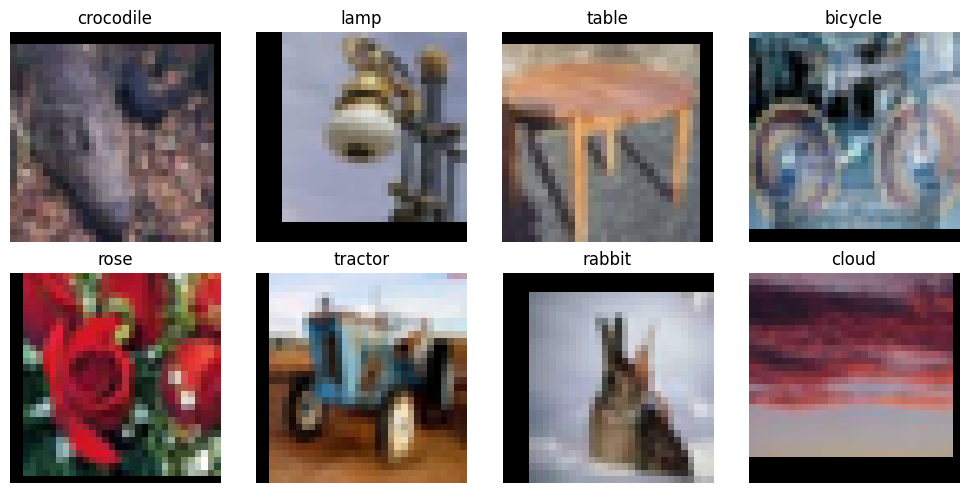

In [23]:
import matplotlib.pyplot as plt

def denormalize(img_tensor, mean=CIFAR100_MEAN, std=CIFAR100_STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(fine_label_names[labels[i].item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Step 8: Training Loop
Matching the paper's recipe (adapted for our scale)

The paper trains with Adam, high weight decay (0.1), linear warmup + decay, and — critically for small-data/from-scratch settings — label smoothing and dropout (Table 3, ImageNet-from-scratch row: lr=3e-3, cosine decay, weight_decay=0.3, dropout=0.1, label smoothing used throughout). We're training on CIFAR-100 from scratch on a much smaller model, so we'll borrow the spirit of this recipe rather than the exact numbers (which were tuned for ViT-Base/JFT-scale training):

In [24]:
import math

def get_lr_scheduler(optimizer, warmup_epochs, total_epochs, steps_per_epoch, base_lr):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch

    def lr_lambda(current_step):
        if current_step < warmup_steps:
            # Linear warmup: 0 -> base_lr
            return current_step / max(1, warmup_steps)
        else:
            # Cosine decay: base_lr -> ~0
            progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
            return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [25]:
NUM_CLASSES = 100
EPOCHS = 50            # start here; we'll extend based on how the loss curve looks
WARMUP_EPOCHS = 5
BASE_LR = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1

model = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3, num_classes=NUM_CLASSES,
    embed_dim=192, depth=6, num_heads=8, mlp_ratio=4.0, dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

steps_per_epoch = len(train_loader)
scheduler = get_lr_scheduler(optimizer, WARMUP_EPOCHS, EPOCHS, steps_per_epoch, BASE_LR)

In [26]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()

        # Gradient clipping -- paper mentions this helps stability (Table 3 footnote)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [27]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_test_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | LR {current_lr:.6f} | "
          f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
          f"test_loss {test_loss:.4f} test_acc {test_acc:.4f}")

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "/kaggle/working/vit_cifar100_best.pth")

print(f"Best test accuracy: {best_test_acc:.4f}")

Epoch   1/50 | LR 0.000060 | train_loss 4.4364 train_acc 0.0415 | test_loss 4.2378 test_acc 0.0729
Epoch   2/50 | LR 0.000120 | train_loss 4.0838 train_acc 0.0978 | test_loss 3.9299 test_acc 0.1250
Epoch   3/50 | LR 0.000180 | train_loss 3.8190 train_acc 0.1456 | test_loss 3.7131 test_acc 0.1631
Epoch   4/50 | LR 0.000240 | train_loss 3.5988 train_acc 0.1882 | test_loss 3.4880 test_acc 0.2024
Epoch   5/50 | LR 0.000300 | train_loss 3.4257 train_acc 0.2221 | test_loss 3.3258 test_acc 0.2410
Epoch   6/50 | LR 0.000300 | train_loss 3.2777 train_acc 0.2590 | test_loss 3.2017 test_acc 0.2790
Epoch   7/50 | LR 0.000299 | train_loss 3.1524 train_acc 0.2874 | test_loss 3.0793 test_acc 0.3017
Epoch   8/50 | LR 0.000297 | train_loss 3.0439 train_acc 0.3143 | test_loss 2.9777 test_acc 0.3320
Epoch   9/50 | LR 0.000294 | train_loss 2.9521 train_acc 0.3367 | test_loss 2.8438 test_acc 0.3698
Epoch  10/50 | LR 0.000291 | train_loss 2.8626 train_acc 0.3601 | test_loss 2.8339 test_acc 0.3732
Epoch  11/

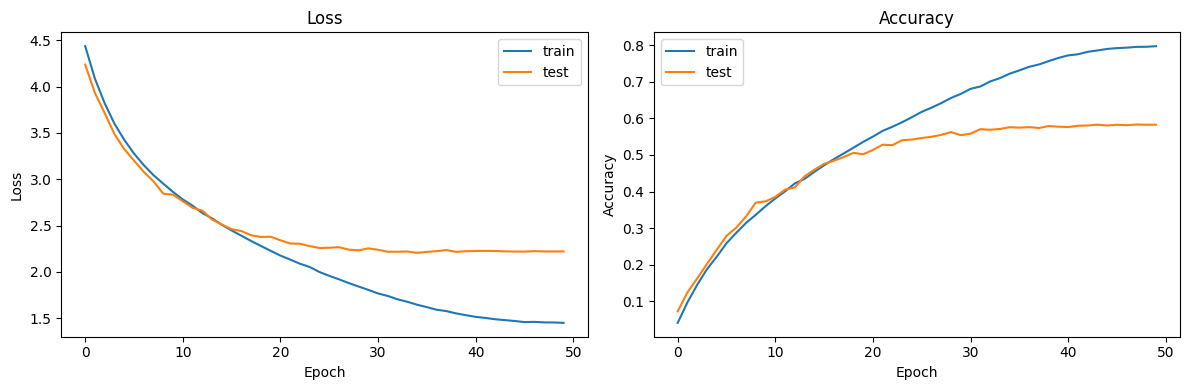

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")

plt.tight_layout()
plt.show()